<a href="https://www.kaggle.com/code/rajeshkm57/ssl-geometry-analysis?scriptVersionId=300411967" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
import pandas as pd

# BYOL vs SimCLR (4 seeds)
df_ssl = pd.DataFrame({
    "Seed": [0,1,2,3],
    "BYOL_Jacobian": [60.391167,57.291708,51.945810,53.439224],
    "SimCLR_Jacobian": [80.724919,76.487283,79.646156,78.381807],
    "BYOL_Noise": [12.249636,13.045829,12.420514,12.700953],
    "SimCLR_Noise": [17.481249,17.660519,17.910130,17.870971],
    "BYOL_Acc": [0.6444,0.6669,0.6583,0.6511],
    "SimCLR_Acc": [0.6936,0.6909,0.6992,0.6944]
})

df_ssl

,Seed,BYOL_Jacobian,SimCLR_Jacobian,BYOL_Noise,SimCLR_Noise,BYOL_Acc,SimCLR_Acc
0,0,60.391167,80.724919,12.249636,17.481249,0.6444,0.6936
1,1,57.291708,76.487283,13.045829,17.660519,0.6669,0.6909
2,2,51.945810,79.646156,12.420514,17.910130,0.6583,0.6992
3,3,53.439224,78.381807,12.700953,17.870971,0.6511,0.6944


In [2]:
df_jac = pd.DataFrame({
    "Seed": [0,1],
    "SimCLR_Jacobian": [89.379337,87.060588],
    "SimCLR_NoJac_Acc": [0.6905,0.6975],
    "SimCLR_NoJac_Noise": [19.091714,18.490107],
    
    "SimCLRJac_Jacobian": [66.768893,66.772942],
    "SimCLRJac_Acc": [0.6760,0.6772],
    "SimCLRJac_Noise": [15.709850,16.561101]
})

df_jac

,Seed,SimCLR_Jacobian,SimCLR_NoJac_Acc,SimCLR_NoJac_Noise,SimCLRJac_Jacobian,SimCLRJac_Acc,SimCLRJac_Noise
0,0,89.379337,0.6905,19.091714,66.768893,0.6760,15.709850
1,1,87.060588,0.6975,18.490107,66.772942,0.6772,16.561101


In [3]:
df_tau = pd.DataFrame({
    "Tau": [0.1,0.1,0.1,0.1,0.5,0.5,0.5,0.5,1.0,1.0,1.0,1.0],
    "Seed": [0,1,2,3,0,1,2,3,0,1,2,3],
    "Jacobian": [
        103.744371,103.285001,105.027203,106.728987,
        91.051254,89.588185,89.435988,89.930428,
        76.823169,75.440114,80.499153,76.942575
    ],
    "Noise": [
        18.529007,19.987349,20.335806,20.474623,
        18.102534,19.135866,19.426159,20.193879,
        18.102741,17.723047,18.563218,20.319879
    ]
})

df_tau

,Tau,Seed,Jacobian,Noise
0,0.1,0,103.744371,18.529007
1,0.1,1,103.285001,19.987349
2,0.1,2,105.027203,20.335806
3,0.1,3,106.728987,20.474623
4,0.5,0,91.051254,18.102534
5,0.5,1,89.588185,19.135866
6,0.5,2,89.435988,19.426159
7,0.5,3,89.930428,20.193879
8,1.0,0,76.823169,18.102741
9,1.0,1,75.440114,17.723047


In [14]:
# -----------------------
# Paired t-tests
# -----------------------

t_jac, p_jac = ttest_rel(df_ssl["SimCLR_Jacobian"],
                         df_ssl["BYOL_Jacobian"])

t_noise, p_noise = ttest_rel(df_ssl["SimCLR_Noise"],
                             df_ssl["BYOL_Noise"])

t_acc, p_acc = ttest_rel(df_ssl["SimCLR_Acc"],
                         df_ssl["BYOL_Acc"])

print("\nPaired t-test Results:")
print(f"Jacobian -> t = {t_jac:.4f}, p = {p_jac:.6f}")
print(f"Noise    -> t = {t_noise:.4f}, p = {p_noise:.6f}")
print(f"Accuracy -> t = {t_acc:.4f}, p = {p_acc:.6f}")


Paired t-test Results:
Jacobian -> t = 11.5891, p = 0.001380
Noise    -> t = 27.8451, p = 0.000102
Accuracy -> t = 7.2794, p = 0.005351


In [15]:
# -----------------------
# Cohen's d (paired)
# -----------------------

def cohens_d_paired(a, b):
    diff = a - b
    return diff.mean() / diff.std(ddof=1)

d_jac = cohens_d_paired(df_ssl["SimCLR_Jacobian"],
                        df_ssl["BYOL_Jacobian"])

d_noise = cohens_d_paired(df_ssl["SimCLR_Noise"],
                          df_ssl["BYOL_Noise"])

d_acc = cohens_d_paired(df_ssl["SimCLR_Acc"],
                        df_ssl["BYOL_Acc"])

print("\nCohen's d (Effect Size):")
print(f"Jacobian d = {d_jac:.4f}")
print(f"Noise d    = {d_noise:.4f}")
print(f"Accuracy d = {d_acc:.4f}")


Cohen's d (Effect Size):
Jacobian d = 5.7945
Noise d    = 13.9226
Accuracy d = 3.6397


In [16]:
print("\n================ SimCLR vs SimCLR+Jac =================")
print("Means:")
print(df_jac.mean())

t_jac_reg, p_jac_reg = ttest_rel(df_jac["SimCLR_Jacobian"],
                                 df_jac["SimCLRJac_Jacobian"])

print("\nPaired t-test (Jacobian Reduction via Regularization):")
print(f"t = {t_jac_reg:.4f}, p = {p_jac_reg:.6f}")

d_jac_reg = cohens_d_paired(df_jac["SimCLR_Jacobian"],
                            df_jac["SimCLRJac_Jacobian"])

print(f"Cohen's d (Jacobian Reduction) = {d_jac_reg:.4f}")



================ SimCLR vs SimCLR+Jac =================
Means:
Seed                   0.500000
SimCLR_Jacobian       88.219963
SimCLR_NoJac_Acc       0.694000
SimCLR_NoJac_Noise    18.790910
SimCLRJac_Jacobian    66.770917
SimCLRJac_Acc          0.676600
SimCLRJac_Noise       16.135475
dtype: float64

Paired t-test (Jacobian Reduction via Regularization):
t = 18.4683, p = 0.034437
Cohen's d (Jacobian Reduction) = 13.0590


In [17]:
print("\n================ Tau Experiment =================")
print("Group Means:")
print(df_tau.groupby("Tau").mean())

# Correlation Tau vs Jacobian
r_tau_jac, p_tau_jac = pearsonr(df_tau["Tau"],
                                df_tau["Jacobian"])

# Correlation Tau vs Noise
r_tau_noise, p_tau_noise = pearsonr(df_tau["Tau"],
                                    df_tau["Noise"])

print("\nCorrelation Results:")
print(f"Tau vs Jacobian -> r = {r_tau_jac:.4f}, p = {p_tau_jac:.6f}")
print(f"Tau vs Noise    -> r = {r_tau_noise:.4f}, p = {p_tau_noise:.6f}")


================ Tau Experiment =================
Group Means:
     Seed    Jacobian      Noise
Tau                             
0.1   1.5  104.696391  19.831696
0.5   1.5   90.001464  19.214609
1.0   1.5   77.426253  18.677221

Correlation Results:
Tau vs Jacobian -> r = -0.9866, p = 0.000000
Tau vs Noise    -> r = -0.4844, p = 0.110530


In [11]:
df_long = pd.melt(
    df_ssl,
    id_vars="Seed",
    value_vars=["BYOL_Jacobian","SimCLR_Jacobian"],
    var_name="Method",
    value_name="Jacobian"
)

df_long["Method"] = df_long["Method"].str.replace("_Jacobian","")

df_long

,Seed,Method,Jacobian
0,0,BYOL,60.391167
1,1,BYOL,57.291708
2,2,BYOL,51.945810
3,3,BYOL,53.439224
4,0,SimCLR,80.724919
5,1,SimCLR,76.487283
6,2,SimCLR,79.646156
7,3,SimCLR,78.381807


<Axes: xlabel='Method', ylabel='Jacobian'>

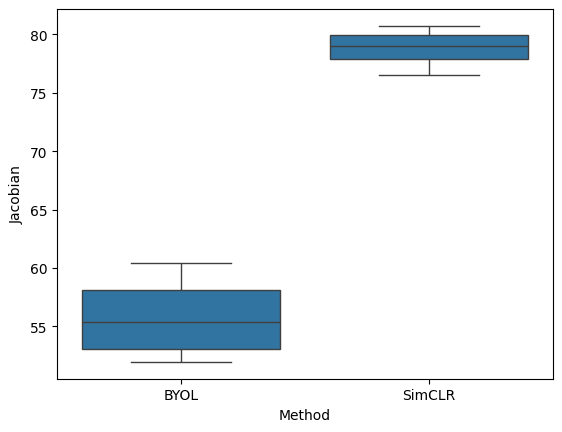

In [12]:
import seaborn as sns
sns.boxplot(data=df_long, x="Method", y="Jacobian")

In [18]:
# ============================================================
# FULL STATISTICAL ANALYSIS CELL (COPY-PASTE READY)
# ============================================================

import pandas as pd
import numpy as np
from scipy.stats import ttest_rel, pearsonr

# ============================================================
# 1️⃣ BYOL vs SimCLR (4 Seeds)
# ============================================================

df_ssl = pd.DataFrame({
    "Seed": [0,1,2,3],
    "BYOL_Jacobian": [60.391167,57.291708,51.945810,53.439224],
    "SimCLR_Jacobian": [80.724919,76.487283,79.646156,78.381807],
    "BYOL_Noise": [12.249636,13.045829,12.420514,12.700953],
    "SimCLR_Noise": [17.481249,17.660519,17.910130,17.870971],
    "BYOL_Acc": [0.6444,0.6669,0.6583,0.6511],
    "SimCLR_Acc": [0.6936,0.6909,0.6992,0.6944]
})

print("\n================ BYOL vs SimCLR =================")
print("Means:")
print(df_ssl.mean())
print("\nStd:")
print(df_ssl.std())


# -----------------------
# Paired t-tests
# -----------------------

t_jac, p_jac = ttest_rel(df_ssl["SimCLR_Jacobian"],
                         df_ssl["BYOL_Jacobian"])

t_noise, p_noise = ttest_rel(df_ssl["SimCLR_Noise"],
                             df_ssl["BYOL_Noise"])

t_acc, p_acc = ttest_rel(df_ssl["SimCLR_Acc"],
                         df_ssl["BYOL_Acc"])

print("\nPaired t-test Results:")
print(f"Jacobian -> t = {t_jac:.4f}, p = {p_jac:.6f}")
print(f"Noise    -> t = {t_noise:.4f}, p = {p_noise:.6f}")
print(f"Accuracy -> t = {t_acc:.4f}, p = {p_acc:.6f}")


# -----------------------
# Cohen's d (paired)
# -----------------------

def cohens_d_paired(a, b):
    diff = a - b
    return diff.mean() / diff.std(ddof=1)

d_jac = cohens_d_paired(df_ssl["SimCLR_Jacobian"],
                        df_ssl["BYOL_Jacobian"])

d_noise = cohens_d_paired(df_ssl["SimCLR_Noise"],
                          df_ssl["BYOL_Noise"])

d_acc = cohens_d_paired(df_ssl["SimCLR_Acc"],
                        df_ssl["BYOL_Acc"])

print("\nCohen's d (Effect Size):")
print(f"Jacobian d = {d_jac:.4f}")
print(f"Noise d    = {d_noise:.4f}")
print(f"Accuracy d = {d_acc:.4f}")


# ============================================================
# 2️⃣ SimCLR vs SimCLR+Jac (2 Seeds)
# ============================================================

df_jac = pd.DataFrame({
    "Seed": [0,1],
    "SimCLR_Jacobian": [89.379337,87.060588],
    "SimCLR_NoJac_Acc": [0.6905,0.6975],
    "SimCLR_NoJac_Noise": [19.091714,18.490107],
    "SimCLRJac_Jacobian": [66.768893,66.772942],
    "SimCLRJac_Acc": [0.6760,0.6772],
    "SimCLRJac_Noise": [15.709850,16.561101]
})

print("\n================ SimCLR vs SimCLR+Jac =================")
print("Means:")
print(df_jac.mean())

t_jac_reg, p_jac_reg = ttest_rel(df_jac["SimCLR_Jacobian"],
                                 df_jac["SimCLRJac_Jacobian"])

print("\nPaired t-test (Jacobian Reduction via Regularization):")
print(f"t = {t_jac_reg:.4f}, p = {p_jac_reg:.6f}")

d_jac_reg = cohens_d_paired(df_jac["SimCLR_Jacobian"],
                            df_jac["SimCLRJac_Jacobian"])

print(f"Cohen's d (Jacobian Reduction) = {d_jac_reg:.4f}")


# ============================================================
# 3️⃣ Tau Experiment (4 Seeds per Tau)
# ============================================================

df_tau = pd.DataFrame({
    "Tau": [0.1,0.1,0.1,0.1,0.5,0.5,0.5,0.5,1.0,1.0,1.0,1.0],
    "Seed": [0,1,2,3,0,1,2,3,0,1,2,3],
    "Jacobian": [
        103.744371,103.285001,105.027203,106.728987,
        91.051254,89.588185,89.435988,89.930428,
        76.823169,75.440114,80.499153,76.942575
    ],
    "Noise": [
        18.529007,19.987349,20.335806,20.474623,
        18.102534,19.135866,19.426159,20.193879,
        18.102741,17.723047,18.563218,20.319879
    ]
})

print("\n================ Tau Experiment =================")
print("Group Means:")
print(df_tau.groupby("Tau").mean())

# Correlation Tau vs Jacobian
r_tau_jac, p_tau_jac = pearsonr(df_tau["Tau"],
                                df_tau["Jacobian"])

# Correlation Tau vs Noise
r_tau_noise, p_tau_noise = pearsonr(df_tau["Tau"],
                                    df_tau["Noise"])

print("\nCorrelation Results:")
print(f"Tau vs Jacobian -> r = {r_tau_jac:.4f}, p = {p_tau_jac:.6f}")
print(f"Tau vs Noise    -> r = {r_tau_noise:.4f}, p = {p_tau_noise:.6f}")

print("\n================ END OF STATISTICAL ANALYSIS =================")


================ BYOL vs SimCLR =================
Means:
Seed                1.500000
BYOL_Jacobian      55.766977
SimCLR_Jacobian    78.810041
BYOL_Noise         12.604233
SimCLR_Noise       17.730717
BYOL_Acc            0.655175
SimCLR_Acc          0.694525
dtype: float64

Std:
Seed               1.290994
BYOL_Jacobian      3.817839
SimCLR_Jacobian    1.820662
BYOL_Noise         0.348259
SimCLR_Noise       0.199184
BYOL_Acc           0.009660
SimCLR_Acc         0.003458
dtype: float64

Paired t-test Results:
Jacobian -> t = 11.5891, p = 0.001380
Noise    -> t = 27.8451, p = 0.000102
Accuracy -> t = 7.2794, p = 0.005351

Cohen's d (Effect Size):
Jacobian d = 5.7945
Noise d    = 13.9226
Accuracy d = 3.6397

================ SimCLR vs SimCLR+Jac =================
Means:
Seed                   0.500000
SimCLR_Jacobian       88.219963
SimCLR_NoJac_Acc       0.694000
SimCLR_NoJac_Noise    18.790910
SimCLRJac_Jacobian    66.770917
SimCLRJac_Acc          0.676600
SimCLRJac_Noise       16.13